# Optimizacion del despacho de almacenamiento en baterias para arbitraje de energia y reduccion de picos

## Resumen ejecutivo

Una instalacion comercial conectada a la red opera una bateria de iones de litio de 2 MW / 8 MWh junto a una carga electrica medida. La instalacion se factura de dos maneras: un **precio de energia** horario del mercado diario ($/MWh) y un **cargo por demanda** mensual sobre su intervalo de importacion de red mas alto ($/MW). El gestor del activo debe decidir, hora a hora, cuando cargar la bateria (comprando energia barata y aumentando la extraccion de la red) y cuando descargarla (compensando energia cara y reduciendo la extraccion de la red). Dos fuentes de valor compiten: el **arbitraje de energia** (comprar barato de madrugada, descargar en el pico de la tarde) y la **reduccion de picos** (limitar el maximo de red facturado). Cargar no es gratis: la eficiencia de ida y vuelta implica que aproximadamente el 10% de la energia almacenada se pierde, de modo que la programacion es una verdadera optimizacion, no una heuristica.

Este cuaderno construye la decision de extremo a extremo. Primero sintetiza una curva realista de precios del mercado diario de 24 horas (con picos por la manana y por la tarde, mas un valle nocturno) y un perfil de carga de la instalacion correlacionado, luego perfila ambos con **PROC MEANS** y una banda de precios robusta de percentiles 2.5/97.5 con **PROC UNIVARIATE**. El nucleo es un programa lineal en **PROC OPTMODEL**: variables de decision para la carga, la descarga y el estado de carga horarios, mas una variable de pico facturado, sujetas a un balance acumulado del estado de carga (con eficiencia de carga/descarga por separado), limites de potencia y capacidad, y una restriccion de definicion del pico. El objetivo maximiza el margen de arbitraje neto del cargo por demanda. **PROC SQL** cuantifica luego el costo de referencia frente al optimizado, y tres paneles de **PROC SGPLOT** visualizan la programacion de carga/descarga frente al precio, la trayectoria del estado de carga y el perfil aplanado de importacion de la red.

**Resultado en el dia sintetico:** el optimizador llena la bateria durante las horas nocturnas mas baratas, la descarga tanto en el pico de precio de la manana como en el de la tarde, la recarga durante el valle de precios de mediodia y, de forma crucial, contiene su potencia de carga para nunca crear un nuevo pico de red. El costo diario de energia cae de **\$2,903.78 a \$2,528.43** — **\$375.34 (12.9%) de ahorro por arbitraje** — mientras que el maximo de red facturado baja de **3.59 MW a 3.43 MW** (aproximadamente **0.16 MW**), lo que vale otros **\$18.98** al cargo por demanda de participacion diaria supuesto. El mismo modelo escala a horizontes mas largos, multiples escenarios de precios o ciclado consciente de la degradacion simplemente ampliando el conjunto de indices y las restricciones.

## Fuentes de datos

Todos los datos son **sinteticos**, generados en linea en la primera celda de codigo con `CALL STREAMINIT(20260605)` para reproducibilidad. Sin archivos externos ni acceso a la red. Un solo conjunto de datos, `price_load`, con 24 filas horarias que representan un unico dia de operacion.

| Variable | Tipo | Unidades | Descripcion |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Hora del dia de operacion (indice del horizonte) |
| `price` | num | $/MWh | Precio de energia del mercado diario: valle nocturno, picos de manana + tarde, con ruido gaussiano (limitado a un minimo de $5) |
| `load` | num | MW | Demanda electrica de la instalacion, correlacionada con la actividad diaria (limitada a un minimo de 0.3 MW) |
| `day_type` | char | — | Indicador de ventana tarifaria: `PeakTOU` (horas 17–21) frente a `OffPeak`, usado para el resumen del diferencial de precio pico/fuera de pico |

Los parametros de la bateria son constantes fijas del modelo dentro de PROC OPTMODEL: 8 MWh de capacidad utilizable, 2 MW de potencia maxima de carga/descarga, 0.95 de eficiencia de carga y 0.95 de descarga (~90% de ida y vuelta), estado de carga inicial de 0 MWh y un cargo por demanda de \$120/MW aplicado al pico de red facturado del dia (la participacion amortizada diariamente de un cargo por demanda mensual).

# Optimizacion del despacho de almacenamiento en baterias
## Arbitraje de energia y reduccion de picos para una instalacion conectada a la red

Una instalacion comercial opera una **bateria de 2 MW / 8 MWh** detras de su medidor. Su factura electrica tiene dos partes: un **precio de energia** horario ($/MWh) y un **cargo por demanda** mensual sobre el intervalo de importacion de red mas alto ($/MW). El operador quiere una programacion horaria de carga/descarga que capture dos fuentes de valor a la vez:

- **Arbitraje** — almacenar energia nocturna barata, liberarla durante las horas pico caras.
- **Reduccion de picos** — descargar durante el pico de demanda para reducir el maximo de red facturado.

Como la eficiencia de ida y vuelta pierde ~10% de la energia almacenada, el compromiso no es trivial y justifica una verdadera optimizacion. La formulamos como un programa lineal en **PROC OPTMODEL**, luego cuantificamos y visualizamos el resultado.

> Todos los datos a continuacion son sinteticos y se generan en linea — el cuaderno es totalmente autonomo y se ejecuta en unos segundos.

## 1. Generar un perfil sintetico de precio del mercado diario y carga

Construimos un dia de operacion (24 filas horarias). La curva de precios tiene un valle nocturno y picos de manana + tarde; la carga de la instalacion esta correlacionada con la actividad diaria. Una semilla fija mantiene la ejecucion reproducible. Tambien etiquetamos la ventana pico de tarifa por hora de uso reglamentaria para poder resumir mas adelante el diferencial pico/fuera de pico.

In [1]:
DATOS price_load;
    LLAMAR streaminit(20260605);
    LONGITUD day_type $12;
    ETIQUETA hour="Hora del día"
             price="Precio ($/MWh)"
             load="Carga (MW)"
             day_type="Tipo de día";
    HACER hour = 0 HASTA 23;
        /* Precio de energía diurno ($/MWh): picos de mañana + tarde */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        SI price < 5 ENTONCES price = 5;

        /* Carga del sitio (MW): valle nocturno, rampa de tarde */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        SI LOAD < 0.3 ENTONCES LOAD = 0.3;

        SI hour >= 17 AND hour <= 21 ENTONCES day_type = 'Pico';
        SINO day_type = 'FueraPico';
        SALIDA;
    END;
    ELIMINAR BASE;
EJECUTAR;


NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Perfilar las distribuciones de precio y carga

Antes de optimizar, verificamos la coherencia de las entradas. El diferencial entre las horas mas baratas y mas caras es lo que el arbitraje monetiza, y la carga maxima ancla la oportunidad de reduccion de picos.

In [2]:
PROCEDIMIENTO MEDIAS DATOS=price_load n mean std MIN MAX maxdec=2;
    VAR price LOAD;
EJECUTAR;

                                                  The MEANS Procedure

 Variable  Label                 N        Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------------------
 price     Precio ($/MWh)       24       46.29       15.81       18.57       79.27
 LOAD      Carga (MW)           24        2.47        0.48        1.71        3.59
 ---------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Diferencial de precio pico frente a fuera de pico

Agrupar por el indicador de hora de uso muestra cuanto mas ricas son las horas pico que la referencia fuera de pico — la senal estructural que la bateria explota.

In [3]:
PROCEDIMIENTO MEDIAS DATOS=price_load mean MIN MAX maxdec=2;
    CLASE day_type;
    VAR price;
EJECUTAR;

                                                  The MEANS Procedure

                                       Analysis Variable : price Precio ($/MWh)

                                                  N
                                Tipo de día     Obs       Mean      Minimum      Maximum
                                --------------------------------------------------------
                                FueraPico        19      40.46        18.57        54.89
                                Pico              5      68.45        54.88        79.27
                                --------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Banda de precios robusta (percentiles 2.5 / 97.5)

Caracterizamos las colas de precios con una banda de percentiles 2.5 / 97.5. **PROC UNIVARIATE** con `PCTLPTS=` calcula percentiles arbitrarios de forma limpia, que es la herramienta correcta para percentiles fraccionarios.

In [4]:
PROCEDIMIENTO UNIVARIATE DATOS=price_load NOPRINT;
    VAR price;
    SALIDA out=price_band pctlpts=2.5 97.5 pctlpre=p_;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=price_band noobs ETIQUETA;
    ETIQUETA p_2_5="Percentil 2.5 ($/MWh)" p_97_5="Percentil 97.5 ($/MWh)";
EJECUTAR;


Percentil 2.5 ($/MWh)  Percentil 97.5 ($/MWh)
---------------------  ----------------------
                18.57                   79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. La optimizacion del despacho (programa lineal)

Leemos el precio y la carga horarios en PROC OPTMODEL y declaramos:

- `chg[h]`, `dis[h]` — potencia horaria de carga / descarga (MW), limitada por la potencia nominal del inversor de 2 MW.
- `soc[h]` — estado de carga (MWh), limitado por la capacidad utilizable de 8 MWh.
- `peak` — el maximo de red facturado (MW).

**Restricciones.** `soc_balance` acumula la energia neta a lo largo de cada hora con eficiencia de carga/descarga por separado (una forma de suma acumulada de la recurrencia horaria). `peak_def` obliga a `peak` a dominar la importacion neta de red de cada hora, de modo que minimizarlo reduce el cargo por demanda.

**Objetivo.** Maximizar el margen de arbitraje — `price × (discharge − charge)` sumado sobre el dia — menos el cargo por demanda sobre el pico facturado. Resolvemos como un LP continuo.

In [5]:
PROCEDIMIENTO optmodel;
    ESTABLECER HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ DATOS price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Battery: 8 MWh usable, 2 MW power, ~90% round-trip efficiency */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Demand charge applied to this day's billed grid peak ($/MW).
       Commercial demand charges are monthly; 120 is the marginal value of
       shaving today's grid maximum once the monthly charge is amortized to
       the day. It is large enough that the optimizer will hold charging
       power back rather than create a new, higher peak. */
    num demand_chg = 120;

    /* Decision variables (MW charge / discharge, MWh state of charge) */
    VAR chg{HOURS}  >= 0 <= p_max;
    VAR dis{HOURS}  >= 0 <= p_max;
    VAR soc{HOURS}  >= 0 <= capacity;
    VAR peak        >= 0;   /* billed grid peak (MW) for demand charge */

    /* Net grid import after battery action (MW) */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Cumulative state of charge: energy in less energy out through hour h,
       with charge/discharge efficiency applied. Equivalent to an hourly
       recurrence but stated as a running sum over prior hours. */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Peak shaving: billed peak is the max grid import across the day */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* Maximize energy-arbitrage margin net of the peak demand charge */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREAR DATOS dispatch DESDE [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. La programacion horaria optima

La tabla resuelta muestra la carga distribuida a lo largo de las horas baratas de la noche y de mediodia — moderada a aproximadamente 1.0–1.7 MW para que nunca establezca un nuevo pico de red — la descarga concentrada en los picos de precio de la manana y la tarde, y el estado de carga trazando un ciclo sensato de llenado y liberacion dentro del limite de 8 MWh. La columna `grid_mw` mantiene un techo plano de ~3.43 MW durante cada hora de carga, la firma de la restriccion de pico activa.

In [6]:
PROCEDIMIENTO IMPRIMIR DATOS=dispatch noobs ETIQUETA;
    VAR hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    ETIQUETA hour="Hora del día" price="Precio ($/MWh)" LOAD="Carga (MW)"
             charge_mw="Carga batería (MW)" discharge_mw="Descarga batería (MW)"
             soc_mwh="Estado de carga (MWh)" grid_mw="Importación de red (MW)";
EJECUTAR;


 Hora del día  Precio ($/MWh)  Carga (MW)   Carga batería (MW)   Descarga batería (MW)  Estado de carga (MWh)   Importación de red (MW)
-------------  --------------  ----------  -------------------  ----------------------  ---------------------  ------------------------
            0           29.73        1.99            1.4418421                       0                1.36975                 3.4318421
            1           28.03        2.16            1.2718421                       0                  2.578                 3.4318421
            2           21.87           2            1.4318421                       0                3.93825                 3.4318421
            3           18.57        1.71            1.7218421                       0                  5.574                 3.4318421
            4           27.62        2.13            1.3018421                       0                6.81075                 3.4318421
            5           36.12        2.18      


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. KPI principales: referencia frente a optimizado

Comparamos la referencia de no hacer nada (pagar el precio de la carga bruta cada hora) frente a la posicion de red optimizada, e informamos el ahorro por arbitraje, la reduccion del pico facturado y el valor en dolares de esa reduccion al cargo por demanda — las dos palancas que impulsan el caso de negocio.

In [7]:
PROCEDIMIENTO SQL;
    CREAR TABLA kpi AS
    SELECCIONAR
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    DESDE dispatch;
QUIT;

PROCEDIMIENTO IMPRIMIR DATOS=kpi noobs ETIQUETA;
    ETIQUETA base_energy_cost="Costo energía base ($)"
             opt_energy_cost="Costo energía optimizado ($)"
             arbitrage_savings="Ahorro por arbitraje ($)"
             base_peak_mw="Pico base (MW)"
             opt_peak_mw="Pico optimizado (MW)"
             peak_reduction_mw="Reducción de pico (MW)"
             demand_charge_savings="Ahorro cargo por demanda ($)";
EJECUTAR;

 Costo energía base ($)   Costo energía optimizado ($)  Ahorro por arbitraje ($)  Pico base (MW)  Pico optimizado (MW)   Reducción de pico (MW)  Ahorro cargo por demanda ($)
-----------------------  -----------------------------  ------------------------  --------------  --------------------  -----------------------  ----------------------------
              2903.7774                2528.4335145526            375.3438854474            3.59             3.4318421                0.1581579                     18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Programacion de carga / descarga frente al precio

La carga (barras azules) y la descarga (linea roja con marcadores) comparten el eje izquierdo en megavatios; el precio del mercado diario (verde discontinuo) se lee en la derecha. La carga se agrupa en las horas baratas de la noche y mediodia, mientras que la descarga se dispara en los picos de precio de la manana y la tarde — la vista confirma que el optimizador compra barato y vende caro.


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


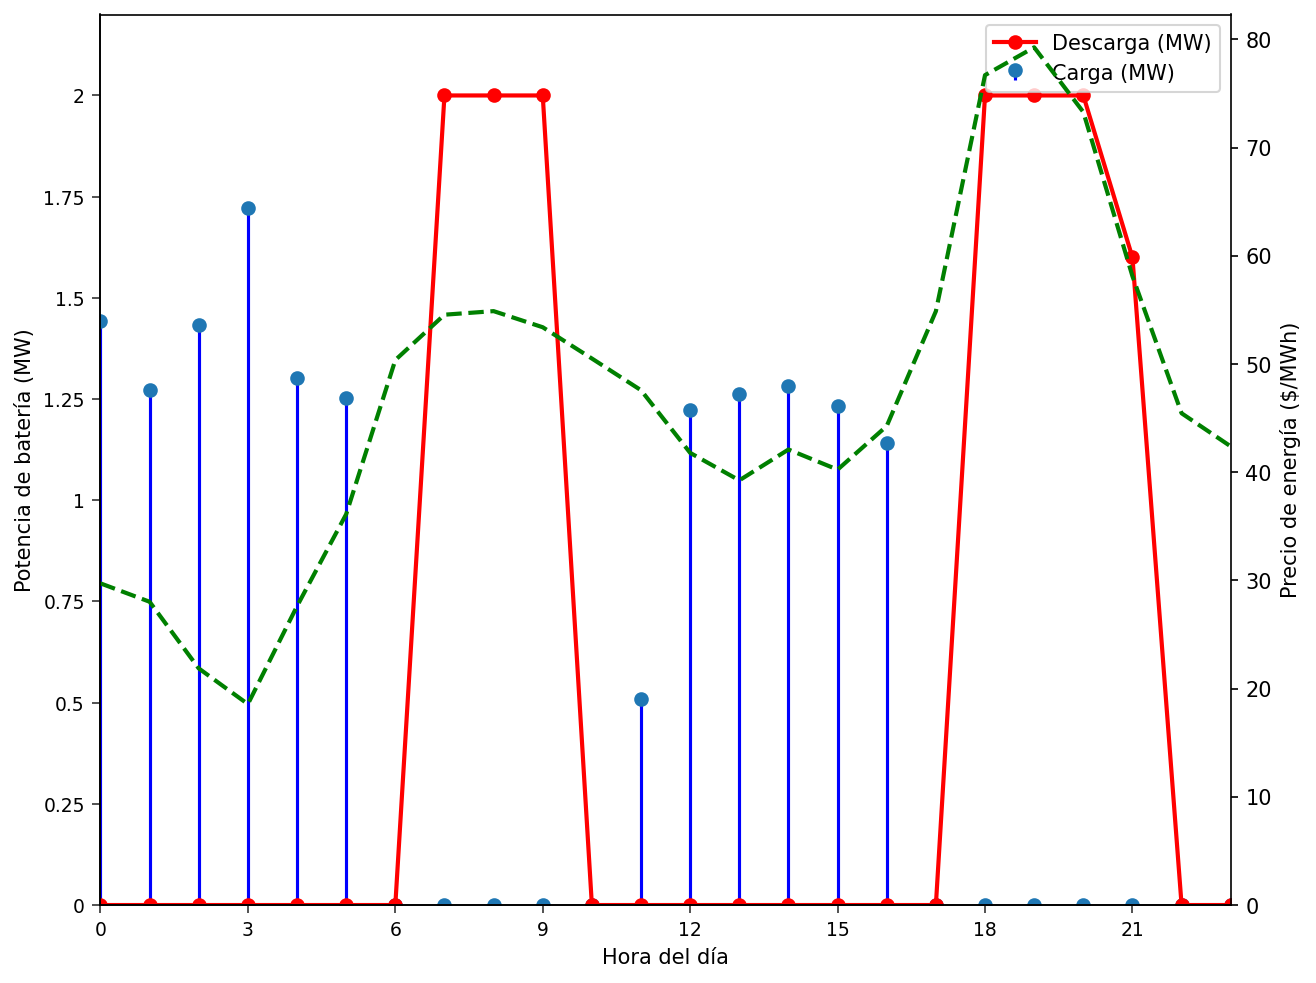

In [8]:
PROCEDIMIENTO SGPLOT DATOS=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Carga (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Descarga (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Precio ($/MWh)";
    XAXIS ETIQUETA="Hora del día" VALUES=(0 HASTA 23 POR 3);
    YAXIS ETIQUETA="Potencia de batería (MW)" MIN=0 MAX=2.2;
    y2axis ETIQUETA="Precio de energía ($/MWh)" MIN=0;
EJECUTAR;

## 9. Trayectoria del estado de carga

La energia almacenada sube a medida que la bateria se llena de madrugada, disminuye a lo largo de cada ventana de descarga y nunca supera el techo de capacidad utilizable de 8 MWh (referencia punteada).


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


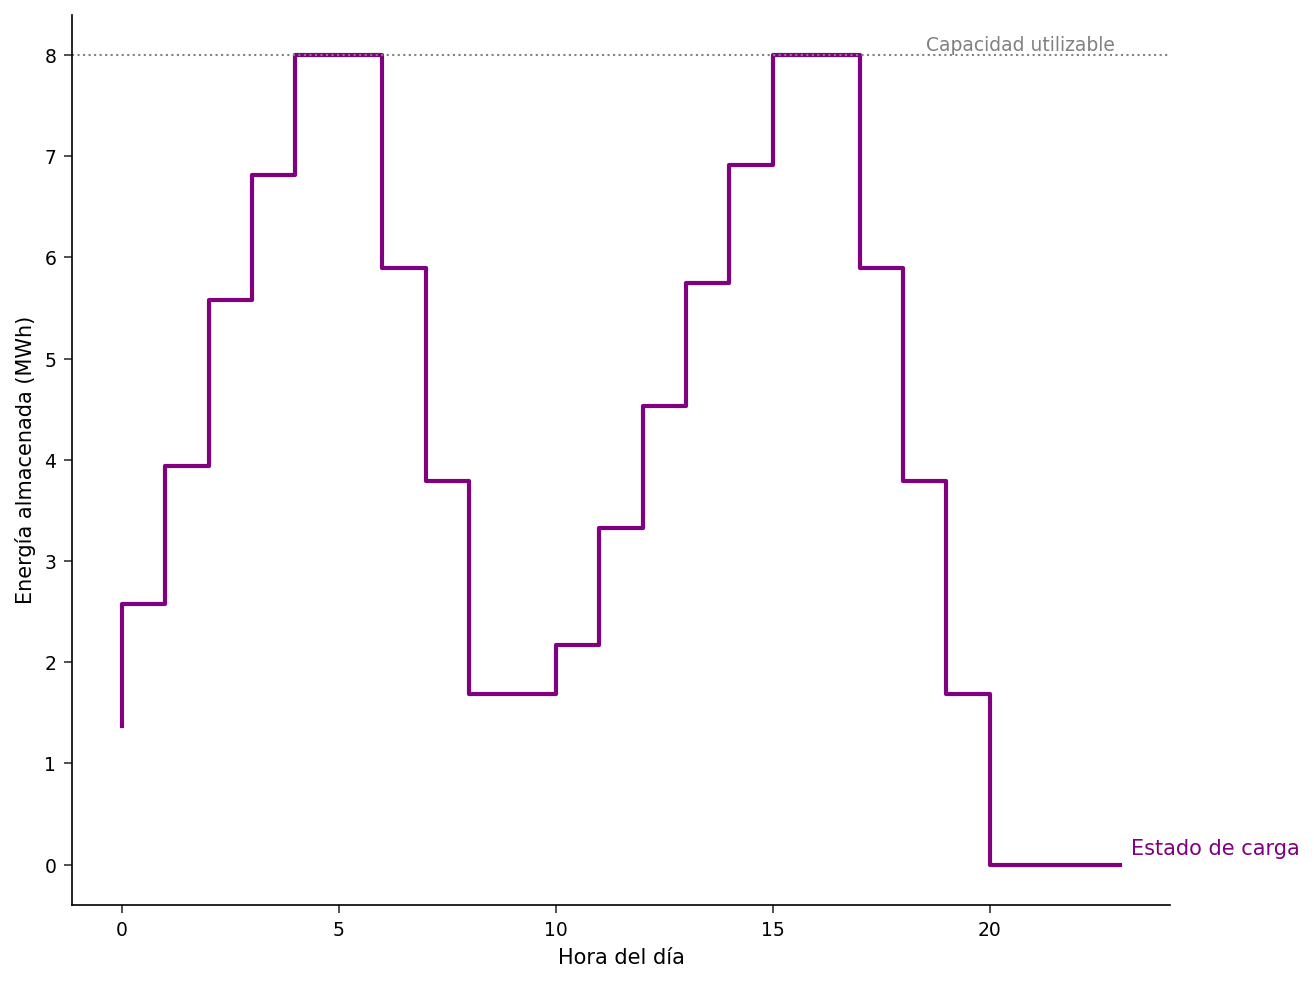

In [9]:
PROCEDIMIENTO SGPLOT DATOS=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Estado de carga";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        ETIQUETA="Capacidad utilizable";
    XAXIS ETIQUETA="Hora del día";
    YAXIS ETIQUETA="Energía almacenada (MWh)";
EJECUTAR;

## 10. Importacion de red: antes frente a despues del despacho

La linea naranja (importacion de red con la bateria) cae muy por debajo de la carga de referencia discontinua durante la rampa de la tarde (horas 18–21) — el efecto de reduccion de picos que baja el cargo por demanda. Durante las ventanas de carga nocturna y de mediodia sube, pero el optimizador la limita a un techo plano de ~3.43 MW que se mantiene *por debajo* del pico de carga original de 3.59 MW, de modo que la carga compra energia barata sin establecer un nuevo maximo facturado.


NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


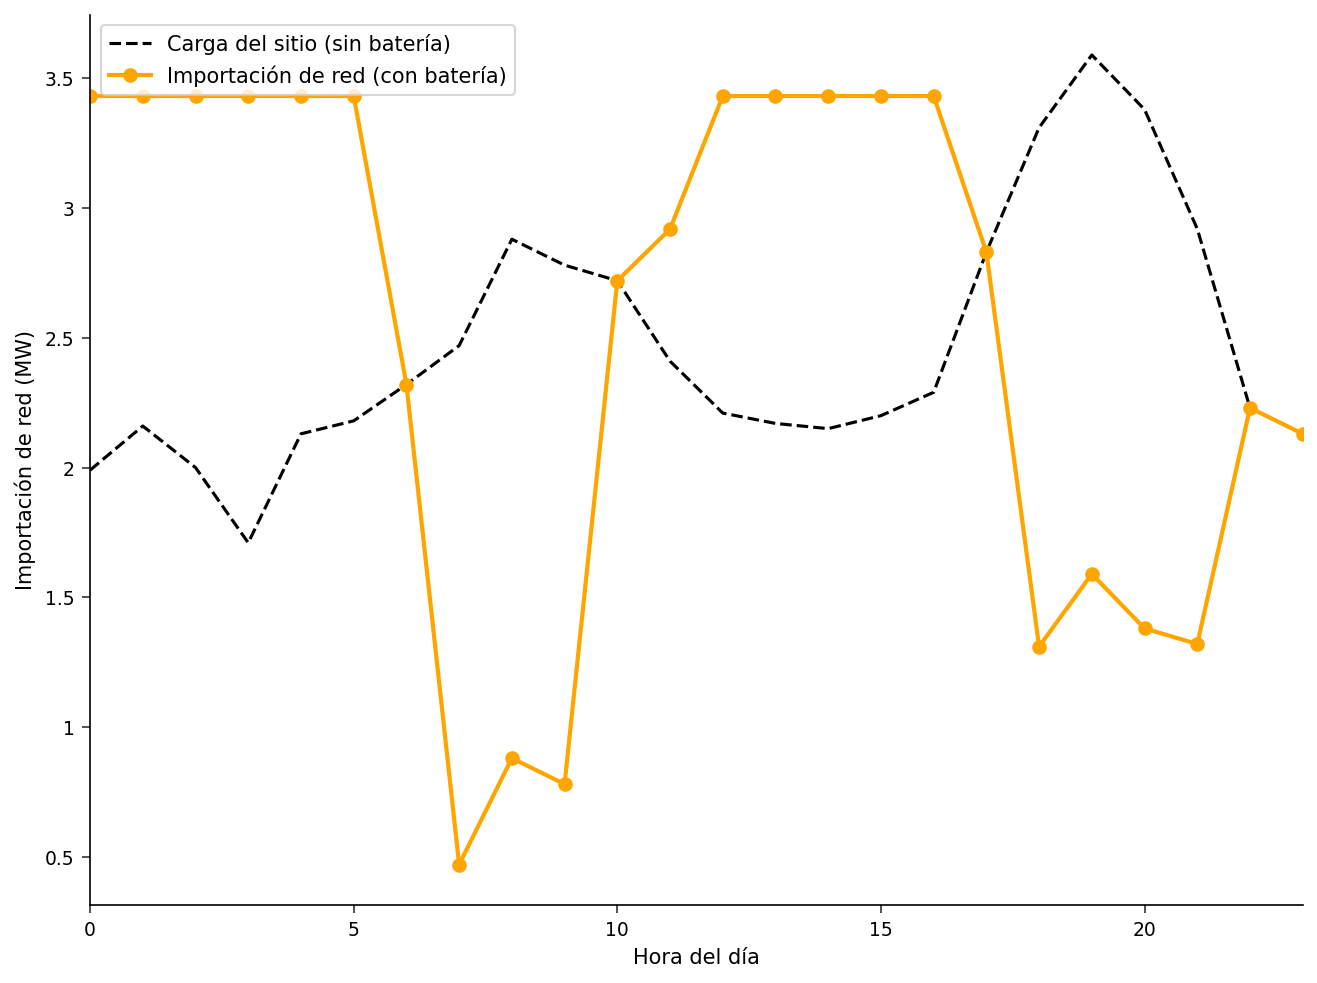

In [10]:
PROCEDIMIENTO SGPLOT DATOS=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Carga del sitio (sin batería)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Importación de red (con batería)";
    XAXIS ETIQUETA="Hora del día";
    YAXIS ETIQUETA="Importación de red (MW)";
EJECUTAR;

## Interpretacion y proximos pasos

**Lo que decidio el modelo.** Con la eficiencia de ida y vuelta gravando cada ciclo, el optimizador aun encontro un valor claro: lleno la bateria durante las horas nocturnas mas baratas, la descargo en el pico de precio de la manana (horas 7–9), la recargo durante el valle de precios de mediodia (horas 11–16) y la descargo de nuevo en el pico de precio mas rico de la tarde (horas 18–21). Notablemente, cargo a solo 1.0–1.7 MW en lugar de la potencia nominal completa de 2 MW durante el llenado nocturno — conteniendo la potencia para que la extraccion de red anadida nunca empujara la importacion por encima del pico de carga del dia. El estado de carga respeto en todo momento tanto la capacidad de 8 MWh como el limite de potencia de 2 MW.

**El caso de negocio.** El costo diario de energia cayo de **\$2,903.78 a \$2,528.43** — **\$375.34 (12.9%)** de ahorro por arbitraje — y el maximo de red facturado bajo de **3.59 MW a 3.43 MW** (aproximadamente **0.16 MW**), recortando otros **\$18.98** de la linea del cargo por demanda. Anualizado a lo largo de los dias de operacion mas la reduccion recurrente del cargo por demanda, este es el tipo de margen que respalda una inversion en almacenamiento.

**Por que un LP es la herramienta correcta.** Las heuristicas ("cargar por debajo del precio mediano, descargar por encima") ignoran las perdidas de eficiencia, el acoplamiento de capacidad entre horas y el hecho de que el cargo por demanda depende de un unico intervalo — cargarian a plena potencia de madrugada y *aumentarian* el pico facturado, destruyendo el valor de la reduccion de picos. PROC OPTMODEL captura todo esto en un solo modelo declarativo y devuelve la programacion demostrablemente optima, que aqui modera deliberadamente la tasa de carga para proteger el pico.

**Ampliar el modelo.**

- **Horizontes mas largos / multiples dias** — ampliar el conjunto de indices `HOURS`; anadir limites de ciclado entre dias.
- **Incertidumbre de precios** — resolver el LP a lo largo de multiples escenarios de precios y promediar la decision de la primera hora (una politica estocastica movil).
- **Degradacion de la bateria** — anadir un termino de penalizacion por rendimiento o una restriccion sobre los ciclos acumulados para equilibrar el arbitraje frente a la vida del activo.
- **Respuesta de frecuencia / mercados de capacidad** — introducir restricciones de margen reservado para que la bateria pueda apilar ingresos de servicios auxiliares sobre el arbitraje.

Todas estas son ediciones incrementales al mismo bloque OPTMODEL — la estructura establecida aqui se mantiene sin cambios.